In [102]:
import grewpy
from grewpy import Corpus, CorpusDraft, Request
from collections import Counter
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting
import tod.dimension_reduction_classic

treebank_path = "/Users/madalina/Documents/PHD/code/data/test/UD_French-GSD"
# treebank_path = "/Users/madalina/Downloads/SUD_French-GSD"
# treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_Chinese-GSD"
# treebank_path = "/Users/madalina/Documents/PHD/code/data/test/UD_Beja-Autogramm"
# treebank_path = "/Users/madalina/Downloads/bUD_English-GUM"
# treebank_path = "/Users/madalina/Documents/PHD/code/data/test/UD_Apurina-UFPA"
# treebank_path = "/Users/madalina/Documents/PHD/code/data/test/UD_Romanian-RRT"
grew_pattern = "pattern{X[upos<>PUNCT]}"
patterns_text_file = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes.txt"
analysed_category = "all_nodes"

corpus = tod.corpus.Corpus(
    treebank_path=treebank_path,
    grew_pattern=grew_pattern,
    patterns_text_file=patterns_text_file,
    use_sud=True,
    matrix_type="coverage",
    # excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"own", r"Gender"]
        # excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"XML=", r"PDTB=", r"SplitAnte=", r"MSeg=", r"Entity=", r"Discourse=", r"Bridge=", r"own", r"Degree=Pos"]
    excluded_feature_patterns=[r"own"],
        included_feature_patterns=[r"upos=", 
                                    r"position=", 
                                    r"rel_shallow=",
                                    r"Abbr=", 
                                    r"Aspect=",  
                                    r"Animacy=",  
                                    r"Case=",  
                                    r"Clusivity=",  
                                    r"Definite=",  
                                    r"Deixis=", 
                                    r"DeixisRef",  
                                    r"Evident=",  
                                    r"Negation=",
                                    r"Number=",  
                                    r"Gender=",  
                                    r"Degree=",  
                                    r"ExtPos=", 
                                    r"Foreign=", 
                                    r"Mood",  
                                    r"NounClass=",  
                                    r"NumType=",  
                                    r"Person=",  
                                    r"Polarity=", 
                                    r"Polite=",  
                                    r"Poss=",  
                                    r"PronType=",  
                                    r"Reflex=",  
                                    r"Tense=",  
                                    r"Typo=",     
                                    r"VerbForm=",  
                                    r"Voice=",   ])
    


In [103]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(corpus.feature_matrix)

In [104]:
import numpy as np
results = []
lex_units_with_different_neighbours = set()
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        if neighbour_category != current_category and similarity_matrix[idx][neighbour_idx] > 0.5:
            diff = np.abs(corpus.feature_matrix[idx] - corpus.feature_matrix[neighbour_idx])
            closest_features_idx= np.argsort(diff)[:-6:-1]
            closest_features = [corpus._idx2feature[i] for i in closest_features_idx]
                
            results.append({
                "lex_unit": lex_unit,
                "neighbour_lex_unit": corpus._idx2lexunit[neighbour_idx],
                "distance": similarity_matrix[idx][neighbour_idx],
                "closest_features": closest_features,
                
            })
            lex_units_with_different_neighbours.add(lex_unit)
    

for r in results:
    print(r)   

{'lex_unit': ('&', 'CCONJ'), 'neighbour_lex_unit': ('di', 'ADP'), 'distance': 0.9467013753043609, 'closest_features': ['node:X:next:upos=PROPN', 'node:X:parent:upos=PROPN', 'node:X:prev:Number=Sing', 'node:X:prev:upos=PROPN', 'node:X:prev:Gender=Fem']}
{'lex_unit': ('&', 'CCONJ'), 'neighbour_lex_unit': ('en', 'ADP'), 'distance': 0.7006773890497091, 'closest_features': ['node:X:parent:upos=PROPN', 'node:X:prev:upos=PROPN', 'node:X:next:upos=PROPN', 'node:X:parent:position=after', 'node:X:next:upos=NUM']}
{'lex_unit': ('&', 'CCONJ'), 'neighbour_lex_unit': ('chez', 'ADP'), 'distance': 0.6734121231644671, 'closest_features': ['node:X:prev:upos=PROPN', 'node:X:parent:position=after', 'node:X:parent:upos=PROPN', 'node:X:next:upos=PROPN', 'node:X:next:upos=DET']}
{'lex_unit': ('&', 'CCONJ'), 'neighbour_lex_unit': ('via', 'ADP'), 'distance': 0.6374743503720702, 'closest_features': ['node:X:next:upos=PROPN', 'node:X:parent:upos=PROPN', 'node:X:prev:upos=PROPN', 'node:X:parent:position=after', '

In [105]:
len(lex_units_with_different_neighbours)

602

In [106]:
category_counts = {}
for idx, lex_unit in corpus._idx2lexunit.items():
    category = lex_unit[1]
    if category not in category_counts:
        category_counts[category] = {"total": 0, "with_different_neighbour": 0}
    category_counts[category]["total"] += 1
    if lex_unit in lex_units_with_different_neighbours:
        category_counts[category]["with_different_neighbour"] += 1

for category, counts in category_counts.items():
    total = counts["total"]
    with_diff = counts["with_different_neighbour"]
    percentage = (with_diff / total) * 100 if total > 0 else 0
    print(f"Category: {category}, Total: {total}, With Different Neighbour: {with_diff}, Percentage: {percentage:.2f}%")

Category: NOUN, Total: 1400, With Different Neighbour: 168, Percentage: 12.00%
Category: CCONJ, Total: 16, With Different Neighbour: 16, Percentage: 100.00%
Category: ADP, Total: 34, With Different Neighbour: 21, Percentage: 61.76%
Category: NUM, Total: 165, With Different Neighbour: 50, Percentage: 30.30%
Category: ADJ, Total: 403, With Different Neighbour: 54, Percentage: 13.40%
Category: VERB, Total: 556, With Different Neighbour: 31, Percentage: 5.58%
Category: PROPN, Total: 172, With Different Neighbour: 142, Percentage: 82.56%
Category: ADV, Total: 122, With Different Neighbour: 53, Percentage: 43.44%
Category: DET, Total: 15, With Different Neighbour: 15, Percentage: 100.00%
Category: PRON, Total: 40, With Different Neighbour: 40, Percentage: 100.00%
Category: AUX, Total: 3, With Different Neighbour: 3, Percentage: 100.00%
Category: INTJ, Total: 2, With Different Neighbour: 2, Percentage: 100.00%
Category: SCONJ, Total: 6, With Different Neighbour: 6, Percentage: 100.00%
Categor

In [107]:
from scipy.stats import entropy
scores = {}
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    purity_top, purity_bottom = 0, 0
    category_weights = {}
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        purity_bottom += distance_to_neighbour # the sum of all the inverse weights
        if neighbour_category in category_weights:
            category_weights[neighbour_category] += distance_to_neighbour
        else:
            category_weights[neighbour_category] = distance_to_neighbour

        if neighbour_category == current_category:
            purity_top += distance_to_neighbour

    purity_score = purity_top / purity_bottom

    probabilities = [v / purity_bottom for v in category_weights.values()]
    entropy_score = entropy(probabilities)
    
    scores[lex_unit] = {}
    scores[lex_unit]["purity"] = purity_score
    scores[lex_unit]["entropy"] = entropy_score

    rival_cat = None
    rival_weight = 0

    for cat, w in category_weights.items():
        if cat != current_category and w > rival_weight:
            rival_weight = w
            rival_cat = cat

    scores[lex_unit]["rival_category"] = rival_cat
    scores[lex_unit]["rival_weight_ratio"] = rival_weight / purity_bottom if purity_bottom > 0 else 0
    

In [108]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
from collections import Counter

# 1. PRE-CALCULATION: Global Category Frequencies (Freq(c))
# This must be done outside the loop to use in the P_norm formula
all_tags = [lu[1] for lu in corpus._idx2lexunit.values()]
total_count = len(all_tags)
category_freqs = {cat: count / total_count for cat, count in Counter(all_tags).items()}

scores = {}

for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    
    # 2. NEIGHBORHOOD SEARCH: Apply 0.7 threshold AND max 20 constraint
    # Find all neighbors with similarity >= 0.7
    threshold_mask = similarity_matrix[idx] >= 0.7
    potential_indices = np.where(threshold_mask)[0]
    
    # Filter out the word itself and sort by similarity (descending)
    valid_neighbours = sorted(
        [i for i in potential_indices if i != idx],
        key=lambda x: similarity_matrix[idx][x],
        reverse=True
    )[:20] # This is your neighborhood cap k=20
    
    if not valid_neighbours:
        continue # Skip words with no strong distributional alignments

    # 3. CALCULATE RAW WEIGHTS (w_i)
    category_weights = {}
    purity_bottom = 0 # This is the sum of similarity weights
    
    for neighbour_idx in valid_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        w_i = similarity_matrix[idx][neighbour_idx]
        purity_bottom += w_i
        category_weights[neighbour_category] = category_weights.get(neighbour_category, 0) + w_i

    # 4. CALCULATE P_norm(c)
    # First, calculate raw P(c) and divide by global frequency
    norm_weights = {}
    for cat, weight in category_weights.items():
        raw_p_c = weight / purity_bottom
        norm_weights[cat] = raw_p_c / category_freqs[cat]
    
    # Re-normalize so the distribution sums to 1 (the denominator in your P_norm formula)
    total_norm_sum = sum(norm_weights.values())
    p_norm = {cat: val / total_norm_sum for cat, val in norm_weights.items()}

    # 5. PURITY AND ENTROPY (Using p_norm)
    # Purity is the mass assigned to the word's own annotated tag
    purity_score = p_norm.get(current_category, 0)
    
    # Entropy calculated on the normalized distribution
    entropy_score = entropy(list(p_norm.values()))
    
    # 6. IDENTIFY RIVAL (For your Bridge Word analysis)
    rival_cat = None
    rival_p = 0
    for cat, p in p_norm.items():
        if cat != current_category and p > rival_p:
            rival_p = p
            rival_cat = cat

    scores[lex_unit] = {
        "purity": purity_score,
        "entropy": entropy_score,
        "rival_category": rival_cat,
        "rival_weight_ratio": rival_p
    }

In [109]:
scores

{('$', 'NOUN'): {'purity': 1.0,
  'entropy': 0.0,
  'rival_category': None,
  'rival_weight_ratio': 0},
 ('%', 'NOUN'): {'purity': 1.0,
  'entropy': 0.0,
  'rival_category': None,
  'rival_weight_ratio': 0},
 ('&', 'CCONJ'): {'purity': 0.6657057911137535,
  'entropy': 0.6371781200869693,
  'rival_category': 'ADP',
  'rival_weight_ratio': 0.33429420888624656},
 ('/', 'ADP'): {'purity': 0.13009488977102407,
  'entropy': 0.941375680684958,
  'rival_category': 'DET',
  'rival_weight_ratio': 0.6499362997765281},
 ('/', 'CCONJ'): {'purity': 0.4624472243719354,
  'entropy': 0.9093438800666647,
  'rival_category': 'ADP',
  'rival_weight_ratio': 0.46156013336949697},
 ('0', 'NUM'): {'purity': 0.8435519449757269,
  'entropy': 0.45962280181519016,
  'rival_category': 'PROPN',
  'rival_weight_ratio': 0.15031072234850296},
 ('1', 'NUM'): {'purity': 0.5145997752282605,
  'entropy': 0.6927208130866607,
  'rival_category': 'ADJ',
  'rival_weight_ratio': 0.48540022477173944},
 ('10', 'NUM'): {'purity':

In [110]:
import plotly.express as px
import pandas as pd

# Convert your 'scores' dictionary to a DataFrame
df = pd.DataFrame.from_dict(scores, orient='index')

# # Assuming lex_unit was a tuple (word, pos)
# df['word'] = df.index.apply(lambda x: x[0])
# df['category'] = df['index'].apply(lambda x: x[1])

# # Calculate medians for the dashed lines
med_p = df['purity'].median()
med_e = df['entropy'].median()

fig = px.scatter(
    df, x="purity", y="entropy",  
    hover_name=list(df.index),
    hover_data={
        "purity": True,
        "entropy": True,
        "rival_category": True,
        "rival_weight_ratio": True
    },
    title="Polycategoriality Analysis: Purity vs Entropy",
    labels={"purity": "Purity (Categorical Homogeneity)", "entropy": "Entropy (Categorical Competition)", "rival_category": "Other category around", "rival_weight_ratio": "Its weight"},
    # template="plotly_dark" # Or "plotly_white"
)

# Add the "Crosshair" at the medians

fig.add_vline(x=med_p, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_hline(y=med_e, line_dash="dash", line_color="gray", opacity=0.5)

fig.show()

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify the 'Rival' for each unit
matrix_data = []

for lex_unit, stats in scores.items():
    current_cat = lex_unit[1]
    
    # We only care about units that have some level of 'pull' from others
    if stats['rival_category'] is not None:
        
       matrix_data.append(
           {
               "Original": current_cat,
               "Rival": stats['rival_category']
           }
       )
df_transitions = pd.DataFrame(matrix_data)
transition_matrix = pd.crosstab(
    df_transitions['Original'], 
    df_transitions['Rival'], 
    normalize='index'
)


In [111]:
all_overlaps = []

for lex_unit, stats in scores.items():
    current_cat = lex_unit[1]
    # Recalculate weights for THIS lex_unit
    idx = corpus._lexunit2idx[lex_unit]
    # closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    # closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    
    # threshold_indices = np.where(similarity_matrix[idx] > 0.7)[0]
    # closest_neighbours = [n_idx for n_idx in threshold_indices if n_idx != idx]

    threshold_indices = np.where(similarity_matrix[idx] > 0.7)[0]

    # 2. Sort those specific indices by similarity score (descending)
    # and take only the top 20 of that subset
    closest_neighbours = sorted(
        [n_idx for n_idx in threshold_indices if n_idx != idx],
        key=lambda x: similarity_matrix[idx][x],
        reverse=True
    )[:20]

    purity_bottom = 0
    category_weights = {}
    
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        purity_bottom += distance_to_neighbour
        
        if neighbour_category in category_weights:
            category_weights[neighbour_category] += distance_to_neighbour
        else:
            category_weights[neighbour_category] = distance_to_neighbour

    for rival_cat, weight in category_weights.items():
        if rival_cat != current_cat:
            all_overlaps.append({
                "Original": current_cat,
                "Rival": rival_cat,
                "Weight": weight / purity_bottom if purity_bottom > 0 else 0
            })

df_overlaps = pd.DataFrame(all_overlaps)
# Group by Original and Rival, then sum the weights and normalize
transition_matrix = df_overlaps.groupby(['Original', 'Rival'])['Weight'].sum().unstack(fill_value=0)
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

In [112]:
transition_matrix = transition_matrix.drop(index="X")

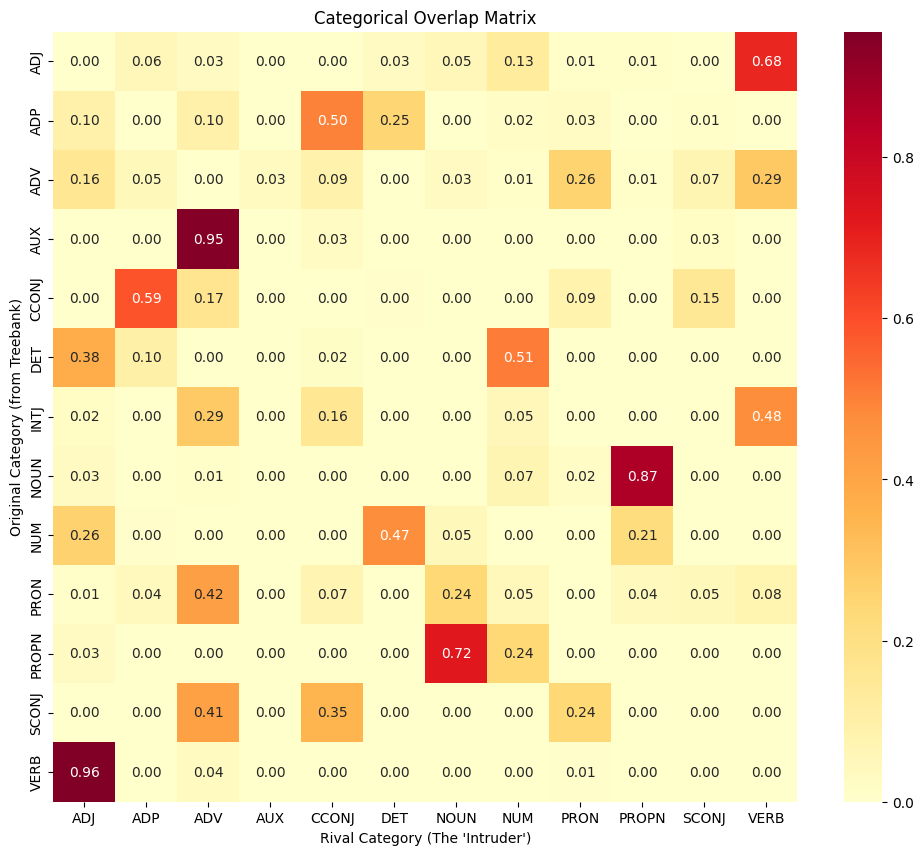

In [113]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    transition_matrix, 
    annot=True,      # Show the numbers in the cells
    cmap="YlOrRd",   # Color gradient: Yellow (low) to Red (high)
    fmt=".2f"        # Format to 2 decimal places
)

plt.title("Categorical Overlap Matrix")
plt.ylabel("Original Category (from Treebank)")
plt.xlabel("Rival Category (The 'Intruder')")
plt.show()

In [114]:
import pandas as pd
from collections import Counter

# 1. Pre-calculate global category frequencies for normalization
all_categories = [lu[1] for lu in corpus._idx2lexunit.values()]
total_count = len(all_categories)
category_freqs = {cat: count / total_count for cat, count in Counter(all_categories).items()}

all_data = []

for idx, lex_unit in corpus._idx2lexunit.items():
    current_cat = lex_unit[1]
    
    # Get neighbors above 0.7 threshold, cap at top 20
    threshold_indices = np.where(similarity_matrix[idx] > 0.7)[0]
    closest_neighbours = sorted(
        [n_idx for n_idx in threshold_indices if n_idx != idx],
        key=lambda x: similarity_matrix[idx][x],
        reverse=True
    )[:20]

    if not closest_neighbours:
        continue

    # Calculate raw category weights for this specific neighborhood
    raw_weights = {}
    total_raw_weight = 0
    for n_idx in closest_neighbours:
        n_cat = corpus._idx2lexunit[n_idx][1]
        sim = similarity_matrix[idx][n_idx]
        raw_weights[n_cat] = raw_weights.get(n_cat, 0) + sim
        total_raw_weight += sim

    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        total_raw_weight += distance_to_neighbour
        
        if neighbour_category in raw_weights:
            raw_weights[neighbour_category] += distance_to_neighbour
        else:
            raw_weights[neighbour_category] = distance_to_neighbour

    # Apply the Normalization by Relative Frequency
    norm_weights = {}
    for cat, weight in raw_weights.items():
        # raw_prob = weight / total_raw_weight
        # normalized_prob = raw_prob / global_frequency_of_cat
        norm_weights[cat] = (weight / total_raw_weight) / category_freqs[cat]
    
    # Re-normalize weights so they sum to 1 for this lex_unit
    sum_norm = sum(norm_weights.values())
    for cat, val in norm_weights.items():
        all_data.append({
            "Original": current_cat,
            "Neighbor_Cat": cat,
            "Normalized_Weight": val / sum_norm
        })

# 2. Build the Transition (Overlap) Matrix
df = pd.DataFrame(all_data)

# Sum all normalized weights for each (Original, Neighbor) pair
# This gives the "Stability" on the diagonal and "Overlap" off-diagonal
matrix = df.groupby(['Original', 'Neighbor_Cat'])['Normalized_Weight'].sum().unstack(fill_value=0)

# Final Normalization: make each ROW sum to 1.0
# This gives the probability: "Given category X, what is the distribution of its neighbors?"
transition_matrix = matrix.div(matrix.sum(axis=1), axis=0)
# transition_matrix = transition_matrix.drop(index="X")

In [98]:
df

,Original,Neighbor_Cat,Normalized_Weight
0,DET,DET,1.000000
1,DET,DET,1.000000
2,DET,DET,0.201207
3,DET,ADJ,0.281504
4,DET,NUM,0.517289
...,...,...,...
3503,NOUN,NOUN,1.000000
3504,NOUN,NOUN,1.000000
3505,VERB,VERB,1.000000
3506,NOUN,NOUN,0.491338


In [115]:
all_data_full = []
all_data_intruders = []

for idx, lex_unit in corpus._idx2lexunit.items():
    current_cat = lex_unit[1]
    
    threshold_indices = np.where(similarity_matrix[idx] > 0.7)[0]
    closest_neighbours = sorted(
        [n_idx for n_idx in threshold_indices if n_idx != idx],
        key=lambda x: similarity_matrix[idx][x], reverse=True
    )[:20]

    if not closest_neighbours: continue

    # 1. Calculate weighted categorical counts for this neighborhood
    raw_weights = {}
    total_raw_weight = 0
    for n_idx in closest_neighbours:
        n_cat = corpus._idx2lexunit[n_idx][1]
        sim = similarity_matrix[idx][n_idx]
        raw_weights[n_cat] = raw_weights.get(n_cat, 0) + sim
        total_raw_weight += sim

    # 2. Normalize by Global Category Frequency (P_norm)
    norm_probs = {}
    for cat, weight in raw_weights.items():
        # Divide relative weight by global frequency
        norm_probs[cat] = (weight / total_raw_weight) / category_freqs[cat]
    
    # Re-normalize to sum to 1
    sum_norm = sum(norm_probs.values())
    for cat in norm_probs:
        norm_probs[cat] /= sum_norm
        
        # # Data for FULL matrix (Stability)
        all_data_full.append({"Original": current_cat, "Neighbor": cat, "Weight": norm_probs[cat]})
        
        # Data for INTRUDER matrix (Zoom)
        # if cat != current_cat:
        #     all_data_intruders.append({"Original": current_cat, "Neighbor": cat, "Weight": norm_probs[cat]})


# 2. Build the Transition (Overlap) Matrix
df = pd.DataFrame(all_data_full)
# df = pd.DataFrame(all_data_intruders)
# Sum all normalized weights for each (Original, Neighbor) pair
# This gives the "Stability" on the diagonal and "Overlap" off-diagonal
matrix = df.groupby(['Original', 'Neighbor'])['Weight'].sum().unstack(fill_value=0)

# Final Normalization: make each ROW sum to 1.0
# This gives the probability: "Given category X, what is the distribution of its neighbors?"
transition_matrix = matrix.div(matrix.sum(axis=1), axis=0)
# transition_matrix = transition_matrix.drop(index="X")
# transition_matrix = transition_matrix.drop(columns="X")
# transition_matrix = transition_matrix.drop(index="SYM")
# transition_matrix = transition_matrix.drop(columns="SYM")

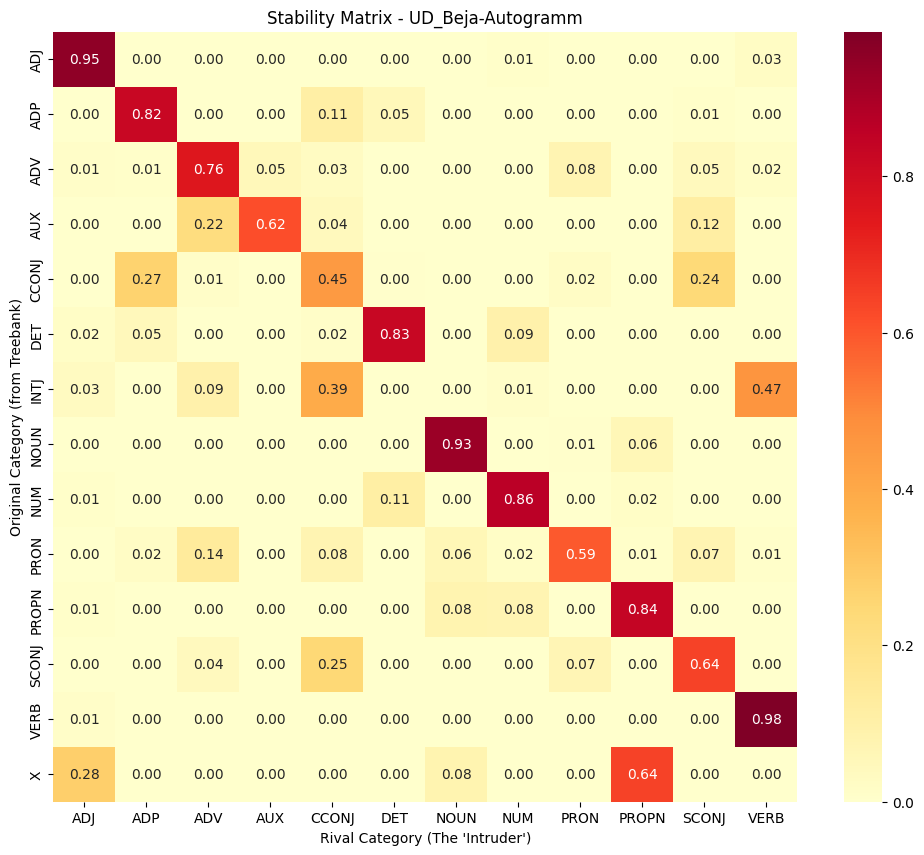

In [116]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    transition_matrix, 
    annot=True,      # Show the numbers in the cells
    cmap="YlOrRd",   # Color gradient: Yellow (low) to Red (high)
    fmt=".2f"        # Format to 2 decimal places
)

plt.title("Stability Matrix - UD_Beja-Autogramm")
plt.ylabel("Original Category (from Treebank)")
plt.xlabel("Rival Category (The 'Intruder')")
plt.show()

In [117]:
import numpy as np
from scipy.stats import entropy as shannon_entropy

word_metrics = []

for idx, lex_unit in corpus._idx2lexunit.items():
    current_cat = lex_unit[1]
    word_str = f"{lex_unit[0]} ({current_cat})"
    
    threshold_indices = np.where(similarity_matrix[idx] > 0.7)[0]
    closest_neighbours = sorted(
        [n_idx for n_idx in threshold_indices if n_idx != idx],
        key=lambda x: similarity_matrix[idx][x], reverse=True
    )[:20]

    if not closest_neighbours: continue

    # 1. Weighted categorical counts
    raw_weights = {}
    total_raw_weight = 0
    for n_idx in closest_neighbours:
        n_cat = corpus._idx2lexunit[n_idx][1]
        sim = similarity_matrix[idx][n_idx]
        raw_weights[n_cat] = raw_weights.get(n_cat, 0) + sim
        total_raw_weight += sim

    # 2. Normalize by Global Category Frequency
    norm_probs = {}
    for cat, weight in raw_weights.items():
        norm_probs[cat] = (weight / total_raw_weight) / category_freqs[cat]
    
    sum_norm = sum(norm_probs.values())
    for cat in norm_probs:
        norm_probs[cat] /= sum_norm
    
    # --- NEW METRICS CALCULATION ---
    # Purity: How much the word looks like its own assigned tag
    purity = norm_probs.get(current_cat, 0)
    
    # Entropy: How scattered the neighbor categories are
    # (Using base 2 so it is measured in bits)
    probs_list = list(norm_probs.values())
    ent = shannon_entropy(probs_list, base=2)
    
    word_metrics.append({
        "word": word_str,
        "category": current_cat,
        "purity": purity,
        "entropy": ent
    })

# Convert to DataFrame for easy filtering
import pandas as pd
results_df = pd.DataFrame(word_metrics)

# Define "High" and "Low" thresholds (using medians is usually safest)
med_pur = results_df['purity'].median()
med_ent = results_df['entropy'].median()

# Define the 4 Quadrants
quadrants = {
    "Mot Prototypique (High Pur, Low Ent)": results_df[(results_df.purity > med_pur) & (results_df.entropy < med_ent)],
    "Mot Pont / Bridge (Low Pur, Low Ent)": results_df[(results_df.purity < med_pur) & (results_df.entropy < med_ent)],
    "Mot Polyvalent (Low Pur, High Ent)": results_df[(results_df.purity < med_pur) & (results_df.entropy > med_ent)],
    "Mot Périphérique (High Pur, High Ent)": results_df[(results_df.purity > med_pur) & (results_df.entropy > med_ent)]
}

# Print top 3 for each
for name, data in quadrants.items():
    print(f"\n--- {name} ---")
    if "Prototypique" in name:
        # For prototypical, we want the highest purity and lowest entropy
        print(data.sort_values(by=['purity', 'entropy'], ascending=[False, True]).head(3))
    elif "Pont" in name:
        # For bridge words, we want lowest purity and lowest entropy
        print(data.sort_values(by=['purity', 'entropy'], ascending=[True, True]).head(3))
    elif "Polyvalent" in name:
        # For polyvalent, lowest purity and highest entropy
        print(data.sort_values(by=['purity', 'entropy'], ascending=[True, False]).head(3))
    else:
        # For peripheral, high purity but highest entropy
        print(data.sort_values(by=['purity', 'entropy'], ascending=[False, False]).head(3))


--- Mot Prototypique (High Pur, Low Ent) ---
Empty DataFrame
Columns: [word, category, purity, entropy]
Index: []

--- Mot Pont / Bridge (Low Pur, Low Ent) ---
Empty DataFrame
Columns: [word, category, purity, entropy]
Index: []

--- Mot Polyvalent (Low Pur, High Ent) ---
             word category  purity   entropy
1239     etc. (X)        X     0.0  1.215892
2480   sien (ADJ)      ADJ     0.0  0.880068
632   bref (INTJ)     INTJ     0.0  0.853883

--- Mot Périphérique (High Pur, High Ent) ---
Empty DataFrame
Columns: [word, category, purity, entropy]
Index: []


In [118]:
import plotly.express as px
import pandas as pd

# Assuming you already have 'results_df' from the previous code
# results_df = pd.DataFrame(word_metrics)

# Calculate medians just to draw visual guide lines on the plot
med_pur = results_df['purity'].median()
med_ent = results_df['entropy'].median()

# Create an interactive scatter plot
fig = px.scatter(
    results_df, 
    x="entropy", 
    y="purity", 
    hover_name="word",       # Shows the word and category when you hover
    color="category",        # Colors the dots by their POS tag
    title="Word Stability: Purity vs. Entropy",
    labels={
        "entropy": "Entropy (Categorical Diversity)",
        "purity": "Purity (Categorical Loyalty)"
    },
    opacity=0.7
)

# Add horizontal and vertical lines to divide the 4 quadrants visually
fig.add_hline(y=med_pur, line_dash="dash", line_color="gray", annotation_text=f"Median Purity ({med_pur:.2f})")
fig.add_vline(x=med_ent, line_dash="dash", line_color="gray", annotation_text=f"Median Entropy ({med_ent:.2f})")

# Add text annotations for the 4 quadrants
fig.add_annotation(x=0, y=1, text="Mot Prototypique<br>(High Pur, Low Ent)", showarrow=False, font=dict(size=12, color="green"), xanchor="left", yanchor="top")
fig.add_annotation(x=results_df['entropy'].max(), y=1, text="Mot Périphérique<br>(High Pur, High Ent)", showarrow=False, font=dict(size=12, color="orange"), xanchor="right", yanchor="top")
fig.add_annotation(x=0, y=0, text="Mot Pont<br>(Low Pur, Low Ent)", showarrow=False, font=dict(size=12, color="red"), xanchor="left", yanchor="bottom")
fig.add_annotation(x=results_df['entropy'].max(), y=0, text="Mot Polyvalent<br>(Low Pur, High Ent)", showarrow=False, font=dict(size=12, color="purple"), xanchor="right", yanchor="bottom")

# Show the interactive plot
fig.show()

In [125]:
import numpy as np
from scipy.stats import entropy as shannon_entropy
import pandas as pd

word_metrics = []

for idx, lex_unit in corpus._idx2lexunit.items():
    current_cat = lex_unit[1]
    word_str = f"{lex_unit[0]} ({current_cat})"
    
    threshold_indices = np.where(similarity_matrix[idx] > 0.7)[0]
    closest_neighbours = sorted(
        [n_idx for n_idx in threshold_indices if n_idx != idx],
        key=lambda x: similarity_matrix[idx][x], reverse=True
    )[:20]

    if not closest_neighbours: continue

    # 1. Weighted categorical counts
    raw_weights = {}
    total_raw_weight = 0
    for n_idx in closest_neighbours:
        n_cat = corpus._idx2lexunit[n_idx][1]
        sim = similarity_matrix[idx][n_idx]
        raw_weights[n_cat] = raw_weights.get(n_cat, 0) + sim
        total_raw_weight += sim

    # 2. Normalize by Global Category Frequency
    norm_probs = {}
    for cat, weight in raw_weights.items():
        norm_probs[cat] = (weight / total_raw_weight) / category_freqs[cat]
    
    sum_norm = sum(norm_probs.values())
    for cat in norm_probs:
        norm_probs[cat] /= sum_norm
    
    # --- METRICS CALCULATION ---
    purity = norm_probs.get(current_cat, 0)
    
    probs_list = list(norm_probs.values())
    ent = shannon_entropy(probs_list, base=2)
    
    # --- FIND THE TARGET CATEGORY ---
    # Find the category with the highest normalized probability in the neighborhood
    target_category = max(norm_probs, key=norm_probs.get)
    target_prob = norm_probs[target_category]
    
    word_metrics.append({
        "word": word_str,
        "original_pos": current_cat,
        "purity": purity,
        "entropy": ent,
        "target_pos": target_category,   # <--- The category it acts as a bridge to
        "target_prob": target_prob       # <--- How strongly it's pulled there (e.g., 0.95)
    })

# Convert to DataFrame
results_df = pd.DataFrame(word_metrics)

# Calculate Averages for Quadrants
med_pur = results_df['purity'].mean()
med_ent = results_df['entropy'].mean()

# Isolate the Bridge Words (Low Purity, Low Entropy)
# We also want to ensure the target_pos is DIFFERENT from the original_pos
bridge_words = results_df[
    (results_df.purity < med_pur) & 
    (results_df.entropy < med_ent) & 
    (results_df.original_pos != results_df.target_pos)
]

# Sort them so the "purest" bridge words (lowest entropy, highest target prob) are at the top
bridge_words = bridge_words.sort_values(by=['entropy', 'target_prob'], ascending=[True, False])

print("\n--- Top Bridge Words (Mot-pont) ---")
print(bridge_words[['word', 'original_pos', 'target_pos', 'target_prob', 'purity', 'entropy']])


--- Top Bridge Words (Mot-pont) ---
                 word original_pos target_pos  target_prob    purity   entropy
171         B (PROPN)        PROPN        ADJ     1.000000  0.000000  0.000000
288   Pokémon (PROPN)        PROPN       NOUN     1.000000  0.000000  0.000000
303    Sahara (PROPN)        PROPN       NOUN     1.000000  0.000000  0.000000
557      autre (PRON)         PRON       NOUN     1.000000  0.000000  0.000000
1003         di (ADP)          ADP      CCONJ     1.000000  0.000000  0.000000
1664    madame (NOUN)         NOUN      PROPN     1.000000  0.000000  0.000000
2333      rien (PRON)         PRON        ADV     1.000000  0.000000  0.000000
2672       tout (ADJ)          ADJ        ADP     1.000000  0.000000  0.000000
2729        un (PRON)         PRON       NOUN     1.000000  0.000000  0.000000
252         M. (NOUN)         NOUN      PROPN     0.993677  0.006323  0.055286
1766  monsieur (NOUN)         NOUN      PROPN     0.986401  0.013599  0.103806


In [128]:
results_df

,word,original_pos,purity,entropy,target_pos,target_prob
0,$ (NOUN),NOUN,1.000000,0.000000,NOUN,1.000000
1,% (NOUN),NOUN,1.000000,0.000000,NOUN,1.000000
2,& (CCONJ),CCONJ,0.665706,0.919254,CCONJ,0.665706
3,/ (ADP),ADP,0.130095,1.358118,DET,0.649936
4,/ (CCONJ),CCONJ,0.462447,1.311906,CCONJ,0.462447
...,...,...,...,...,...,...
2927,œil (NOUN),NOUN,1.000000,0.000000,NOUN,1.000000
2928,œuf (NOUN),NOUN,1.000000,0.000000,NOUN,1.000000
2929,œuvre (NOUN),NOUN,1.000000,0.000000,NOUN,1.000000
2930,œuvrer (VERB),VERB,1.000000,0.000000,VERB,1.000000


In [130]:
import numpy as np
from scipy.stats import entropy as shannon_entropy
import pandas as pd

word_metrics = []

for idx, lex_unit in corpus._idx2lexunit.items():
    current_cat = lex_unit[1]
    word_str = f"{lex_unit[0]} ({current_cat})"
    
    threshold_indices = np.where(similarity_matrix[idx] > 0.7)[0]
    closest_neighbours = sorted(
        [n_idx for n_idx in threshold_indices if n_idx != idx],
        key=lambda x: similarity_matrix[idx][x], reverse=True
    )[:20]

    if not closest_neighbours: continue

    raw_weights = {}
    total_raw_weight = 0
    for n_idx in closest_neighbours:
        n_cat = corpus._idx2lexunit[n_idx][1]
        sim = similarity_matrix[idx][n_idx]
        raw_weights[n_cat] = raw_weights.get(n_cat, 0) + sim
        total_raw_weight += sim

    norm_probs = {}
    for cat, weight in raw_weights.items():
        norm_probs[cat] = (weight / total_raw_weight) / category_freqs[cat]
    
    sum_norm = sum(norm_probs.values())
    for cat in norm_probs:
        norm_probs[cat] /= sum_norm
    
    purity = norm_probs.get(current_cat, 0)
    probs_list = list(norm_probs.values())
    ent = shannon_entropy(probs_list, base=2)
    
    # --- NEW: CAPTURE THE FULL DISTRIBUTION ---
    # Sort the categories by probability (highest first) and ignore tiny traces (< 0.05)
    # This creates a readable string like "ADV: 0.40, PRON: 0.35, SCONJ: 0.15"
    sorted_dist = sorted(norm_probs.items(), key=lambda x: x[1], reverse=True)
    dist_str = ", ".join([f"{cat}: {prob:.2f}" for cat, prob in sorted_dist if prob >= 0.05])
    
    word_metrics.append({
        "word": word_str,
        "original_pos": current_cat,
        "purity": purity,
        "entropy": ent,
        "distribution": dist_str  # <--- Saving the full profile here!
    })

# Convert to DataFrame
results_df = pd.DataFrame(word_metrics)

# --- Define Linguistic Thresholds ---
HIGH_PUR_THRESHOLD = 0.80
LOW_PUR_THRESHOLD = 0.50
HIGH_ENT_THRESHOLD = 1.50

# Extract Polyvalent words
polyvalent = results_df[
    (results_df.purity <= LOW_PUR_THRESHOLD) & 
    (results_df.entropy >= HIGH_ENT_THRESHOLD)
]

print("\n--- Mot Polyvalent (Low Pur, High Ent) ---")
# Sort by highest entropy first
polyvalent_sorted = polyvalent.sort_values(by='entropy', ascending=False)

# Print the word, its original tag, its entropy, and the full breakdown!
# We use pandas display options to ensure the 'distribution' column doesn't get cut off
pd.set_option('display.max_colwidth', None)
print(polyvalent_sorted[['word', 'entropy', 'distribution']])


--- Mot Polyvalent (Low Pur, High Ent) ---
                    word   entropy  \
2616          tant (ADV)  1.994725   
1995     personne (PRON)  1.969135   
1244    eux-mêmes (PRON)  1.901222   
1837           non (ADV)  1.890133   
563          avant (ADV)  1.874977   
2673          tout (ADV)  1.818312   
2924          être (AUX)  1.774978   
1585         juste (ADV)  1.755916   
1640          loin (ADV)  1.727990   
1238          et (CCONJ)  1.723471   
544         autant (ADV)  1.687272   
276   Notre-Dame (PROPN)  1.617679   
2826          web (NOUN)  1.580989   
1184         enfin (ADV)  1.576779   
1813          même (ADV)  1.573877   
1314        fidèle (ADJ)  1.562408   
2787     vis-à-vis (ADV)  1.554983   
1646          lors (ADV)  1.533226   
1584        jusque (ADP)  1.531363   
1693        mardi (NOUN)  1.517765   
1063        donc (CCONJ)  1.500143   

                                         distribution  
2616   SCONJ: 0.31, AUX: 0.30, CCONJ: 0.29, ADV: 0.08  
1995  S

In [66]:
def calculate_weighted_stability(transition_matrix, category_counts):
    """
    Calculates the Weighted Average Stability of a language.
    
    Args:
        transition_matrix (pd.DataFrame): The full overlap matrix (rows sum to 1).
        category_counts (dict/Series): The frequency of each category (e.g., token counts).
    
    Returns:
        float: The WAS score (0.0 to 1.0).
    """
    # 1. Get the diagonal (Stability of each category)
    # np.diag extracts the diagonal; we match it with index to ensure alignment
    categories = transition_matrix.index
    stability_scores = pd.Series(np.diag(transition_matrix), index=categories)
    
    # 2. Align the counts with the categories present in the matrix
    weights = pd.Series(category_counts).reindex(categories).fillna(0)
    
    # 3. Calculate Weighted Average
    total_weight = weights.sum()
    if total_weight == 0: return 0
    
    weighted_stability = (stability_scores * weights).sum() / total_weight
    
    return weighted_stability

# --- Usage ---
# Use all_data_full to build the matrix
df_full = pd.DataFrame(all_data_full)
# 1. Get the list of all unique categories present in the data (both as source and neighbor)
all_categories = sorted(list(set(df_full['Original']).union(set(df_full['Neighbor']))))

# 2. Build the matrix
matrix_full = df_full.groupby(['Original', 'Neighbor'])['Weight'].sum().unstack(fill_value=0)

# 3. FORCE the matrix to be square
# This adds the missing columns/rows filled with 0s
matrix_full = matrix_full.reindex(index=all_categories, columns=all_categories, fill_value=0)

# 4. Final Normalization (Rows sum to 1.0)
# We add a small epsilon or check for zero-sum rows to avoid division by zero
row_sums = matrix_full.sum(axis=1)
full_transition_matrix = matrix_full.div(row_sums.replace(0, 1), axis=0)

# Calculate the score
was_score = calculate_weighted_stability(full_transition_matrix, category_freqs)
print(f"Global Weighted Stability for this language: {was_score:.4f}")

Global Weighted Stability for this language: 0.8377


In [96]:
def get_top_bridge_words(scores_dict, original_cat, rival_cat, top_n=100):
    """Finds the words from original_cat most pulled toward rival_cat."""
    matches = []

    for (word, o_cat), data in scores_dict.items():
        if o_cat == original_cat and data["rival_category"] == rival_cat:
            matches.append({
                "word": word,
                "purity": float(data["purity"]),
                "entropy": float(data["entropy"]),
            })

    matches.sort(
        key=lambda x: (0.7 * x["purity"] - 0.3 * x["entropy"]),
        reverse=False
    )

    return [(m["word"], f'{m["purity"]:.2f}', f'{m["entropy"]:.2f}') for m in matches[:top_n]]

# Example: Who are the Verbs that look like Adjectives?
category_to_compare_1 = "PART"
category_to_compare_2 = "PRON"
bridge_verbs = get_top_bridge_words(scores, category_to_compare_1, category_to_compare_2)
print(f"Top {category_to_compare_1} -> {category_to_compare_2} bridge words: ")
print(f"Word \t Purity \t Entropy")
for v in bridge_verbs:
    print(v)

Top PART -> PRON bridge words: 
Word 	 Purity 	 Entropy


In [21]:
def get_pulling_features(lex_unit, rival_category, corpus, similarity_matrix, top_k_features=20):
    lex_unit_vector = corpus.feature_matrix[corpus._lexunit2idx[lex_unit]]
    threshold_indices = np.where(similarity_matrix[corpus._lexunit2idx[lex_unit]] > 0.7)[0]

    # 2. Sort those specific indices by similarity score (descending)
    # and take only the top 20 of that subset
    closest_neighbours = sorted(
        [n_idx for n_idx in threshold_indices if n_idx != idx],
        key=lambda x: similarity_matrix[idx][x],
        reverse=True
    )[:20]

    rival_cat_neighbours_idx = []
    for i in closest_neighbours:
        if i != corpus._lexunit2idx[lex_unit] and corpus._idx2lexunit[i][1] == rival_category:
            rival_cat_neighbours_idx.append(i)
    
    rival_centroid = np.median(corpus.feature_matrix[rival_cat_neighbours_idx[:20]], axis=0)
    
    feat_idx_to_compare = []
    for feature_value_idx in range(len(rival_centroid)):
        if rival_centroid[feature_value_idx] > 0:
            feat_idx_to_compare.append(feature_value_idx)

    diffs = {}
    for f in feat_idx_to_compare:
        diff = abs(lex_unit_vector[f] - rival_centroid[f])
        diffs[f] = diff

    feature_differences = np.abs(lex_unit_vector - rival_centroid)
    
    global_variance = np.var(corpus.feature_matrix, axis=0)

    bridge_score = global_variance / (feature_differences + 1e-6)
    top_feature_indices = np.argsort(bridge_score)[::-1][:top_k_features]

    most_similar_features = {}
    for i in range(len(feature_differences)):
        if feature_differences[i] > 0:
            most_similar_features[corpus._idx2feature[i]] = feature_differences[i]
    
    sorted_most_similar_features = {k: v for k, v in sorted(most_similar_features.items(), key = lambda item: item[1])}
    print(sorted_most_similar_features)
    # We rank by (Value / (Difference + epsilon)) 
    # This prioritizes high-frequency features that match the rival perfectly
    relevance_score = lex_unit_vector / (feature_differences + 1e-6)
    top_feature_indices = np.argsort(relevance_score)[::-1][:top_k_features]
    # print(top_feature_indices)
    results = []
    for f_idx in top_feature_indices:
        # print(corpus._idx2feature[f_idx])
        results.append(
            {
            "feature": corpus._idx2feature[f_idx],
            "unit_value": lex_unit_vector[f_idx],
            "rival_avg": rival_centroid[f_idx],
            "diff": feature_differences[f_idx]
            }
        )


In [22]:
get_pulling_features(('intituler', 'VERB'), "ADJ", corpus, similarity_matrix)

{'node:X:parent:VerbForm=Part': 2.9665344067082017e-08, 'node:X:child:upos=SCONJ': 5.587730545652094e-05, 'node:X:prev:Gender=Masc': 0.00013540950463544537, 'node:X:parent:upos=ADJ': 0.0002902748034306567, 'node:X:child:Person=3': 0.000911445021151364, 'node:X:child:rel_shallow=mark': 0.0011260964607820588, 'node:X:child:rel_shallow=parataxis': 0.0011261261261261261, 'node:X:parent:Gender=Fem': 0.0011261261261261261, 'node:X:parent:Voice=Pass': 0.0011261261261261261, 'node:X:parent:upos=PRON': 0.0011261261261261261, 'node:X:next:upos=ADJ': 0.00112618545681426, 'node:X:next:upos=ADV': 0.001145611585629959, 'node:X:prev:upos=ADJ': 0.001145611585629959, 'node:X:child:Number=Plur': 0.001161099213722627, 'node:X:child:rel_shallow=case': 0.001182033096926714, 'node:X:next:VerbForm=Part': 0.001182033096926714, 'node:X:next:Voice=Pass': 0.001182033096926714, 'node:X:parent:position=after': 0.001182033096926714, 'node:X:prev:upos=DET': 0.001182033096926714, 'node:X:child:rel_shallow=cc': 0.0012

In [ ]:
result = get_pulling_features(('willing', 'ADJ'), "VERB", corpus, similarity_matrix)
print(result)

In [23]:
def get_pulling_features(lex_unit, rival_category, corpus, similarity_matrix, 
                        similarity_threshold=0.7, n_neighbors=20, top_k_features=20):
    """
    Identifies features that 'pull' a lexical unit toward a rival category.
    
    Args:
        lex_unit: Tuple of (word, category)
        rival_category: The competing category (e.g., "VERB" if analyzing noun-verb overlap)
        corpus: Corpus object with feature_matrix and mapping dictionaries
        similarity_matrix: Precomputed cosine similarity matrix
        similarity_threshold: Minimum similarity to consider a neighbor (default: 0.7)
        n_neighbors: Max neighbors to consider (default: 20)
        top_k_features: Number of top features to return (default: 20)
    
    Returns:
        List of dicts with feature name, unit value, rival avg, and difference
    """
    
    # 1. GET LEXICAL UNIT VECTOR
    unit_idx = corpus._lexunit2idx[lex_unit]
    lex_unit_vector = corpus.feature_matrix[unit_idx]
    
    # 2. FIND SIMILAR NEIGHBORS FROM RIVAL CATEGORY
    # Get all indices above similarity threshold
    similar_indices = np.where(similarity_matrix[unit_idx] > similarity_threshold)[0]
    
    # Sort by similarity (descending) and take top n_neighbors
    similar_indices_sorted = sorted(
        [idx for idx in similar_indices if idx != unit_idx],
        key=lambda x: similarity_matrix[unit_idx][x],
        reverse=True
    )[:n_neighbors]
    
    # Filter for rival category only
    rival_neighbors_idx = [
        idx for idx in similar_indices_sorted 
        if corpus._idx2lexunit[idx][1] == rival_category
    ]
    
    if len(rival_neighbors_idx) == 0:
        print(f"Warning: No neighbors found in category '{rival_category}' above threshold {similarity_threshold}")
        return []
    
    # 3. COMPUTE RIVAL PROTOTYPE (using median for robustness)
    rival_centroid = np.median(
        corpus.feature_matrix[rival_neighbors_idx[:n_neighbors]], 
        axis=0
    )
    
    # 4. CALCULATE FEATURE DIFFERENCES
    feature_differences = np.abs(lex_unit_vector - rival_centroid)
    
    # 5. RANK FEATURES BY "PULLING POWER"
    # Strategy: Features with high values in BOTH unit and rival, but small difference
    # Formula: unit_value / (difference + epsilon)
    # Higher score = feature is shared strongly with rival
    epsilon = 1e-6
    pulling_score = lex_unit_vector / (feature_differences + epsilon)
    
    # Get top-k feature indices
    top_feature_indices = np.argsort(pulling_score)[::-1][:top_k_features]
    
    # 6. BUILD RESULTS
    results = []
    for f_idx in top_feature_indices:
        results.append({
            "feature": corpus._idx2feature[f_idx],
            "unit_value": float(lex_unit_vector[f_idx]),
            "rival_avg": float(rival_centroid[f_idx]),
            "difference": float(feature_differences[f_idx]),
            # "pulling_score": float(pulling_score[f_idx])
        })
    
    results.sort(
        key=lambda x: (x["unit_value"]),
        reverse=True
    )
    return results[:top_k_features]


# USAGE EXAMPLE
result = get_pulling_features(
    lex_unit=('censé', 'ADJ'), 
    rival_category="VERB", 
    corpus=corpus, 
    similarity_matrix=similarity_matrix,
    top_k_features=15
)

# Pretty print results
import pandas as pd
df_result = pd.DataFrame(result)
print(df_result.to_string(index=False))

                       feature  unit_value  rival_avg  difference
 node:X:parent:position=before    0.056410   0.050575    0.005835
      node:X:child:Number=Sing    0.041026   0.036426    0.004600
        node:X:child:upos=VERB    0.035897   0.035241    0.000657
       node:X:child:upos=PUNCT    0.035897   0.030594    0.005304
node:X:child:rel_shallow=punct    0.035897   0.030594    0.005304
     node:X:child:VerbForm=Inf    0.035897   0.025079    0.010819
         node:X:child:Person=3    0.025641   0.024684    0.000957
        node:X:child:upos=PRON    0.020513   0.020819    0.000306
          node:X:prev:Person=3    0.020513   0.019769    0.000744
     node:X:child:PronType=Prs    0.015385   0.016119    0.000734
         node:X:child:Case=Nom    0.015385   0.013880    0.001504
       node:X:child:Tense=Pres    0.015385   0.013772    0.001612
        node:X:prev:Tense=Pres    0.010256   0.007870    0.002386
          node:X:prev:upos=ADV    0.005128   0.005705    0.000577
          

In [ ]:
def get_aggregate_pulling_features(scores_dict, original_cat, rival_cat, corpus, 
                                    similarity_matrix, top_k_words=10, top_k_features=20,
                                    similarity_threshold=0.7, n_neighbors=20):
    """
    Gets the top k 'bridge words' and computes aggregate pulling features across them.
    
    Args:
        scores_dict: Dictionary from the scores calculation
        original_cat: Original category (e.g., "ADJ")
        rival_cat: Rival category (e.g., "VERB")
        corpus: Corpus object
        similarity_matrix: Precomputed cosine similarity matrix
        top_k_words: Number of top bridge words to analyze (default: 10)
        top_k_features: Number of top features to return (default: 20)
        similarity_threshold: Threshold for neighbor similarity (default: 0.7)
        n_neighbors: Max neighbors to consider (default: 20)
    
    Returns:
        DataFrame with aggregated feature statistics across the top k words
    """
    
    # 1. GET TOP K BRIDGE WORDS
    bridge_words = get_top_bridge_words(scores_dict, original_cat, rival_cat, top_n=top_k_words)
    
    if not bridge_words:
        print(f"No bridge words found from {original_cat} to {rival_cat}")
        return None
    
    print(f"Analyzing {len(bridge_words)} bridge words: {[w[0] for w in bridge_words]}\n")
    
    # 2. COLLECT PULLING FEATURES FOR EACH WORD
    all_features_data = {}  # feature_name -> list of unit_values across words
    
    for word, purity_str, entropy_str in bridge_words:
        lex_unit = (word, original_cat)
        
        # Get pulling features for this word
        features = get_pulling_features(
            lex_unit=lex_unit,
            rival_category=rival_cat,
            corpus=corpus,
            similarity_matrix=similarity_matrix,
            similarity_threshold=similarity_threshold,
            n_neighbors=n_neighbors,
            top_k_features=top_k_features * 2  # Get more to aggregate
        )
        
        if not features:
            continue
        
        # Store unit values for each feature
        for feature_dict in features:
            feat_name = feature_dict["feature"]
            unit_val = feature_dict["unit_value"]
            
            if feat_name not in all_features_data:
                all_features_data[feat_name] = []
            all_features_data[feat_name].append(unit_val)
    
    # 3. AGGREGATE STATISTICS ACROSS WORDS
    aggregate_results = []
    
    for feature_name, unit_values in all_features_data.items():
        aggregate_results.append({
            "feature": feature_name,
            "avg_unit_value": float(np.mean(unit_values)),
            "median_unit_value": float(np.median(unit_values)),
            "std_unit_value": float(np.std(unit_values)),
            "count_words": len(unit_values),  # How many words had this feature
        })
    
    # 4. SORT BY AVERAGE UNIT VALUE (descending)
    aggregate_results.sort(
        key=lambda x: x["avg_unit_value"],
        reverse=True
    )
    
    # 5. CONVERT TO DATAFRAME
    df_aggregate = pd.DataFrame(aggregate_results[:top_k_features])
    
    return df_aggregate


# USAGE EXAMPLE
df_agg = get_aggregate_pulling_features(
    scores_dict=scores,
    original_cat="PART",
    rival_cat="PRON",
    corpus=corpus,
    similarity_matrix=similarity_matrix,
    top_k_words=5,
    top_k_features=20,
)

print(df_agg.to_string(index=False))

No bridge words found from PART to PRON


AttributeError: 'NoneType' object has no attribute 'to_string'